In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

### Load and Examine the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\HP\Desktop\Ai project\asteroid_close_approaches_2015_2035 (1).csv")
df

,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude,is_future
0,2022 AP1,(2022 AP1),2015-01-01 00:27,0.045100,6746806.0,17.55,0.013778,0.076571,11.891749,42810.0,11.886780,28.39,False
1,2015 AE45,(2015 AE45),2015-01-02 15:56,0.048239,7216474.0,18.77,0.048220,0.048258,7.065686,25436.0,7.057864,25.30,False
2,613286,613286 (2005 YQ96),2015-01-02 21:46,0.026522,3967664.0,10.32,0.026522,0.026522,12.703378,45732.0,12.695467,20.63,False
3,2014 YQ34,(2014 YQ34),2015-01-03 13:29,0.079692,11921722.0,31.01,0.078275,0.081108,24.982094,89936.0,24.980756,24.16,False
4,2014 YE42,(2014 YE42),2015-01-03 15:00,0.010995,1644896.0,4.28,0.010971,0.011020,13.998882,50396.0,13.981561,23.40,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27425,2025 AC1,(2025 AC1),2035-12-26 08:22,0.083559,12500228.0,32.52,0.066438,0.100799,8.709480,31354.0,8.705818,26.89,True
27426,2024 YF1,(2024 YF1),2035-12-27 13:18,0.089199,13343971.0,34.71,0.088964,0.141531,10.708675,38551.0,10.705885,23.54,True
27427,2025 PN7,(2025 PN7),2035-12-27 21:30,0.058551,8759067.0,22.79,0.058549,0.058552,1.831257,6593.0,1.806236,26.41,True
27428,2022 YS6,(2022 YS6),2035-12-28 08:54,0.024968,3735173.0,9.72,0.004201,0.046292,9.403958,33854.0,9.392603,26.86,True


In [3]:
df.tail()

,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude,is_future
27425,2025 AC1,(2025 AC1),2035-12-26 08:22,0.083559,12500228.0,32.52,0.066438,0.100799,8.709480,31354.0,8.705818,26.89,True
27426,2024 YF1,(2024 YF1),2035-12-27 13:18,0.089199,13343971.0,34.71,0.088964,0.141531,10.708675,38551.0,10.705885,23.54,True
27427,2025 PN7,(2025 PN7),2035-12-27 21:30,0.058551,8759067.0,22.79,0.058549,0.058552,1.831257,6593.0,1.806236,26.41,True
27428,2022 YS6,(2022 YS6),2035-12-28 08:54,0.024968,3735173.0,9.72,0.004201,0.046292,9.403958,33854.0,9.392603,26.86,True
27429,2024 WX15,(2024 WX15),2035-12-29 10:15,0.060425,9039430.0,23.52,0.059768,0.062458,5.940014,21384.0,5.932586,24.27,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27430 entries, 0 to 27429
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             27430 non-null  object 
 1   full_name               27430 non-null  object 
 2   close_approach_date     27430 non-null  object 
 3   distance_au             27430 non-null  float64
 4   dist_km                 27430 non-null  float64
 5   dist_lunar              27430 non-null  float64
 6   distance_min_au         27430 non-null  float64
 7   distance_max_au         27430 non-null  float64
 8   velocity_km_s           27430 non-null  float64
 9   v_rel_kmh               27430 non-null  float64
 10  velocity_infinity_km_s  27413 non-null  float64
 11  absolute_magnitude      27422 non-null  float64
 12  is_future               27430 non-null  bool   
dtypes: bool(1), float64(9), object(3)
memory usage: 2.5+ MB


### Handle Null Values

In [5]:
df.isna().sum()

designation                0
full_name                  0
close_approach_date        0
distance_au                0
dist_km                    0
dist_lunar                 0
distance_min_au            0
distance_max_au            0
velocity_km_s              0
v_rel_kmh                  0
velocity_infinity_km_s    17
absolute_magnitude         8
is_future                  0
dtype: int64

In [6]:
df.fillna({
    'velocity_infinity_km_s': df['velocity_infinity_km_s'].mean(),
    'absolute_magnitude': df['absolute_magnitude'].mean(),
}, inplace=True)

In [7]:
df.isna().sum()

designation               0
full_name                 0
close_approach_date       0
distance_au               0
dist_km                   0
dist_lunar                0
distance_min_au           0
distance_max_au           0
velocity_km_s             0
v_rel_kmh                 0
velocity_infinity_km_s    0
absolute_magnitude        0
is_future                 0
dtype: int64

### Handle Duplicated Values

In [8]:
df.duplicated().sum()

np.int64(0)

### Handle Objects

In [9]:
cla_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cla_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude,is_future
0,11183,11100,0,0.045100,6746806.0,17.55,0.013778,0.076571,11.891749,42810.0,11.886780,28.39,False
1,1283,1200,1,0.048239,7216474.0,18.77,0.048220,0.048258,7.065686,25436.0,7.057864,25.30,False
2,20699,20731,2,0.026522,3967664.0,10.32,0.026522,0.026522,12.703378,45732.0,12.695467,20.63,False
3,1272,1189,3,0.079692,11921722.0,31.01,0.078275,0.081108,24.982094,89936.0,24.980756,24.16,False
4,1267,1184,4,0.010995,1644896.0,4.28,0.010971,0.011020,13.998882,50396.0,13.981561,23.40,False


### EDA Report

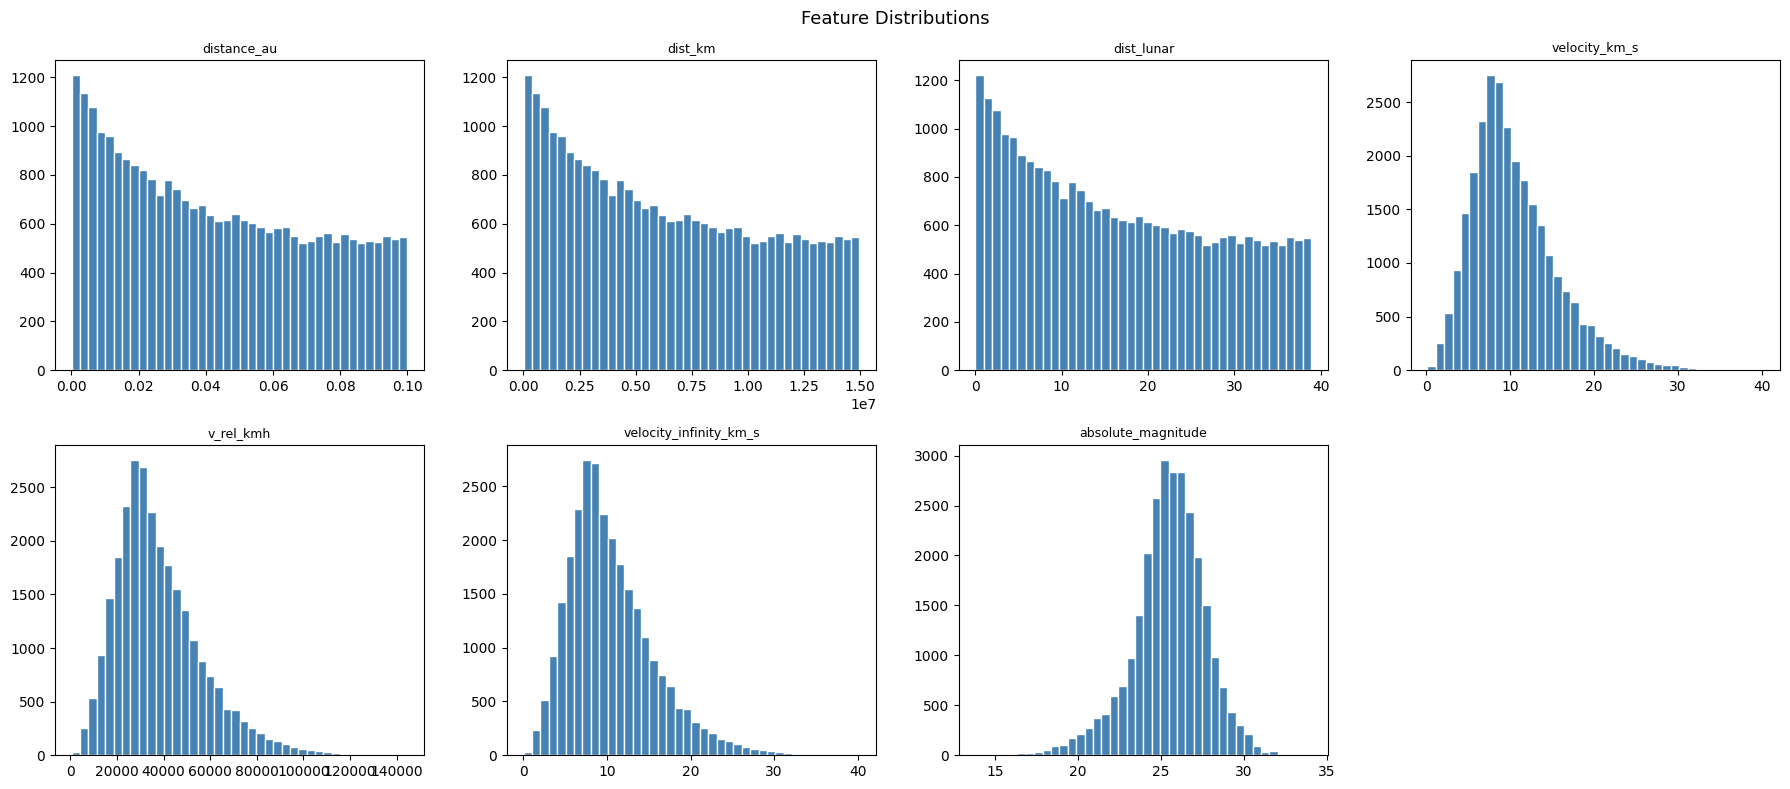

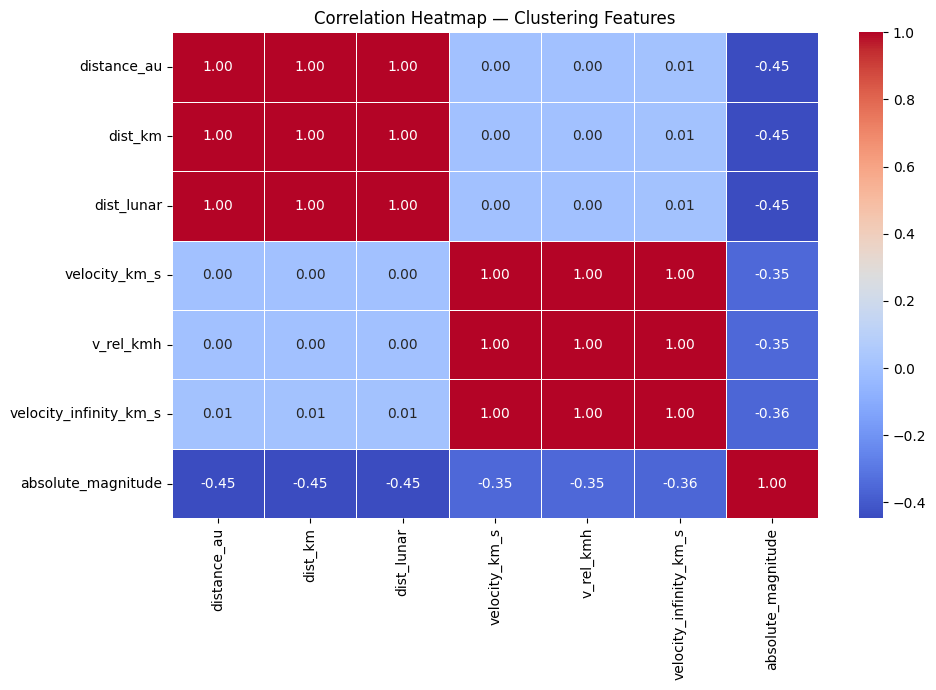

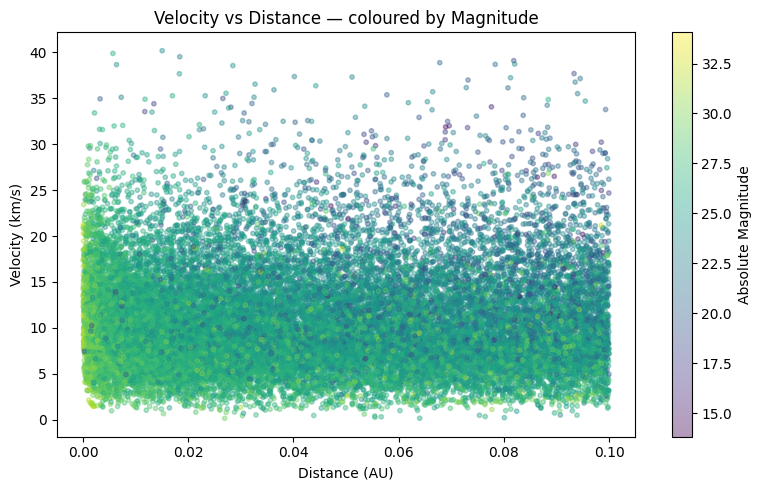

In [10]:
feature_cols = ['distance_au', 'dist_km', 'dist_lunar',
                'velocity_km_s', 'v_rel_kmh',
                'velocity_infinity_km_s', 'absolute_magnitude']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
axes[-1].set_visible(False)
plt.suptitle("Feature Distributions", fontsize=13)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap — Clustering Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sc = plt.scatter(df['distance_au'], df['velocity_km_s'],
                 c=df['absolute_magnitude'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(sc, label='Absolute Magnitude')
plt.xlabel("Distance (AU)")
plt.ylabel("Velocity (km/s)")
plt.title("Velocity vs Distance — coloured by Magnitude")
plt.tight_layout()
plt.show()

## Scaling

In [11]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(df[feature_cols])
x_scaled_df = pd.DataFrame(x_scaled, columns=feature_cols)

print("Features scaled to [0, 1] range")
x_scaled_df.describe().round(3)

Features scaled to [0, 1] range


,distance_au,dist_km,dist_lunar,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude
count,27430.000,27430.000,27430.000,27430.000,27430.000,27430.000,27430.000
mean,0.432,0.432,0.432,0.260,0.260,0.261,0.575
std,0.295,0.295,0.295,0.131,0.131,0.131,0.109
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.167,0.167,0.167,0.169,0.169,0.171,0.518
50%,0.395,0.395,0.395,0.234,0.234,0.236,0.582
75%,0.681,0.681,0.681,0.328,0.328,0.329,0.643
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## PCA

Explained variance ratio: [0.81311947 0.16303971]
Total explained variance: 97.62%


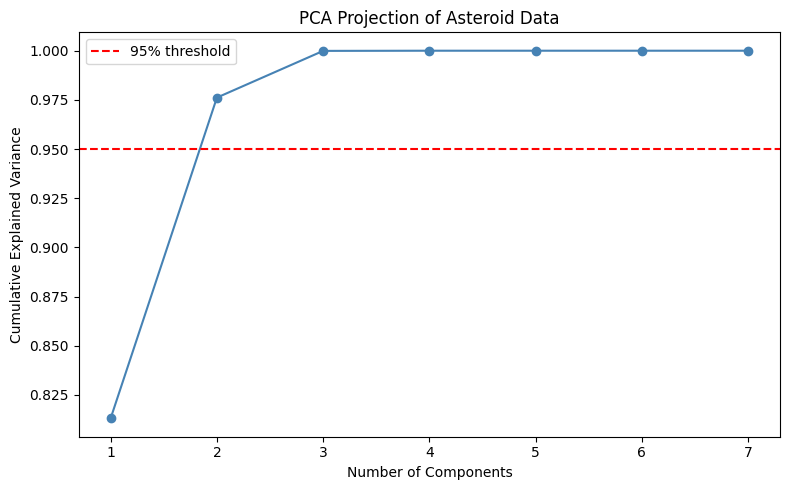

In [12]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled_df)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(8, 5))
pcaf = PCA(random_state=42).fit(x_scaled_df)
plt.plot(range(1, len(pcaf.explained_variance_ratio_)+1),
         np.cumsum(pcaf.explained_variance_ratio_), marker='o', color='steelblue')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Projection of Asteroid Data")
plt.legend()
plt.tight_layout()
plt.show()

### Elbow Method

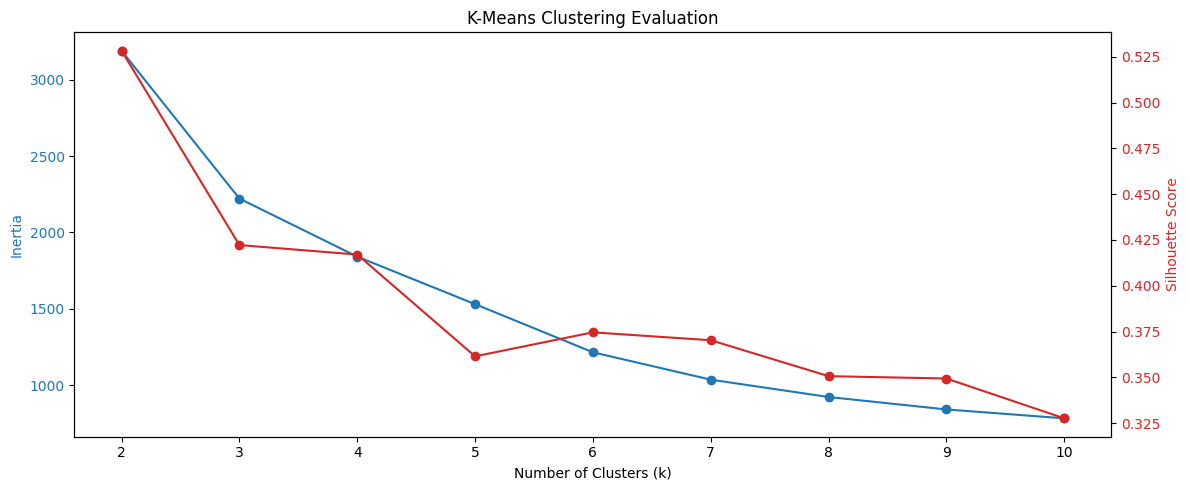

Best k by silhouette: 2 (score = 0.528)
Suggested k by elbow: 5


In [13]:
K = range(2, 11)
inertia = []
silhouette = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_pca)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(x_pca, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(12, 5))
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(K, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K, silhouette, marker='o', color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.title("K-Means Clustering Evaluation")
plt.tight_layout()
plt.show()

best_k_silhouette = K[np.argmax(silhouette)]
diffs = np.diff(inertia)
elbow_k = K[np.argmin(np.diff(diffs)) + 1]

print(f"Best k by silhouette: {best_k_silhouette} (score = {max(silhouette):.3f})")
print(f"Suggested k by elbow: {elbow_k}")

### Training Kmeans

In [14]:
kmeans = KMeans(n_clusters=best_k_silhouette, random_state=42)
df['cluster'] = kmeans.fit_predict(x_pca)

print(f"KMeans trained with k={best_k_silhouette}")
print("\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

KMeans trained with k=2

Cluster distribution:
cluster
0    15409
1    12021
Name: count, dtype: int64


### Heatmap

         distance_au       dist_km  dist_lunar  velocity_km_s  v_rel_kmh  velocity_infinity_km_s  absolute_magnitude
cluster                                                                                                             
0              0.021  3.070150e+06       7.987          10.49  37765.136                  10.444              26.195
1              0.072  1.083424e+07      28.185          10.64  38305.676                  10.638              24.505


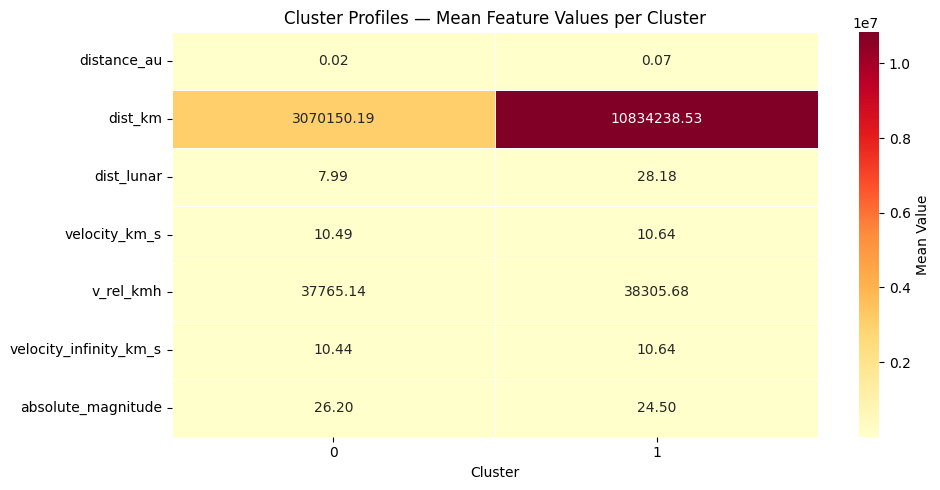

In [15]:
cluster_profile = df.groupby('cluster')[feature_cols].mean().round(3)
print(cluster_profile.to_string())

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile.T, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title("Cluster Profiles — Mean Feature Values per Cluster")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

### Cluster scatter plot 

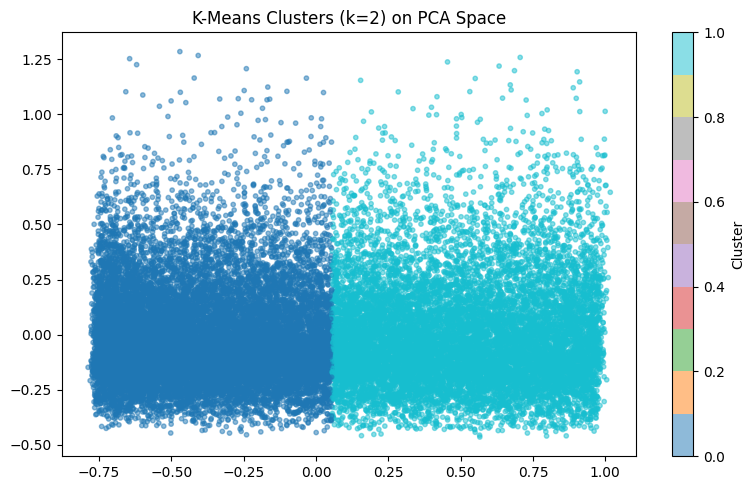

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=df['cluster'], cmap='tab10', alpha=0.5, s=10)
plt.title(f"K-Means Clusters (k={best_k_silhouette}) on PCA Space")
plt.colorbar(label='Cluster')
plt.tight_layout()